In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Importações do Scikit-learn e Imbalanced-learn ---
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from scipy import sparse
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Funções Auxiliares ---
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Adicionar checagem para evitar divisão por zero se não houver negativos reais
    if (tn + fp) == 0:
        return 1.0
    return tn / (tn + fp)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),  # Aproximadamente 14.28%, que corresponde a 10% do dataset total.
    random_state=42,
    stratify=y_full
)

#------ rus = RandomUnderSampler(random_state=42)
#------ X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)
#------ X_train, y_train = X_train_bal, y_train_bal

# Verificar as dimensões finais
print("Divisão final dos dados (sem vstack):")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

# --- PCA de Redução de Dimensionalidade ---
# número de componentes: ajuste conforme variância que queira preservar
# --- pca = PCA(n_components=1000, random_state=42)
# --- X_train_pca = pca.fit_transform(X_train)
# --- X_val_pca   = pca.transform(X_val)
# --- X_test_pca  = pca.transform(X_test)

X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

# Salvar o modelo de PCA para aplicar exatamente a mesma transformação depois
# --- pca_path = os.path.join(processed_data_path, 'pca_model.pkl')
# --- joblib.dump(pca, pca_path)
# --- print(f"PCA treinado e salvo em: {pca_path}")
# --- print(f"Formas após PCA → Treino: {X_train_pca.shape}, Validação: {X_val_pca.shape}, Teste: {X_test_pca.shape}")

Formato do dataset completo (X): (95029, 294)
Formato do dataset completo (y): (95029,)
---
Divisão final dos dados (sem vstack):
Treino (X, y):    	(81453, 294), (81453,)
Validação (X, y): 	(13576, 294), (13576,)
Teste (X, y):     	(56303, 294), (56303,)


In [3]:
# Aplicar SMOTE *apenas* no conjunto de treino para evitar data leakage
print("--- ANTES DO SMOTE ---")
print(f"Distribuição em y_train: {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_pca, y_train)

print("\n--- DEPOIS DO SMOTE ---")
print(f"Formato de X_train_resampled: {X_train_resampled.shape}")
print(f"Distribuição em y_train_resampled: {np.bincount(y_train_resampled)}")

--- ANTES DO SMOTE ---
Distribuição em y_train: [21235 60218]

--- DEPOIS DO SMOTE ---
Formato de X_train_resampled: (120436, 294)
Distribuição em y_train_resampled: [60218 60218]


In [4]:
# Grade de hiperparâmetros a ser explorada
param_grid = {
    'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    #'n_estimators': [10],
    'max_depth': [10, 20, None]
}

# Número de repetições para cada combinação
n_repeats = 5

# Lista para armazenar os resultados de cada execução
results_list = []

print("Grade de parâmetros e número de repetições definidos.")

Grade de parâmetros e número de repetições definidos.


In [6]:
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

total_runs = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * n_repeats
current_run = 0

print(f"Iniciando a busca em grade... Total de {total_runs} execuções.")

# Loop sobre cada combinação de hiperparâmetro
for n_est in param_grid['n_estimators']:
    for m_depth in param_grid['max_depth']:
        for i in range(n_repeats):
            current_run += 1
            print(f"Execução {current_run}/{total_runs}: n_est={n_est}, max_depth={m_depth}, rep={i+1}")

            # Instanciar o modelo
            model = XGBClassifier(
                n_estimators=n_est,
                max_depth=m_depth,
                random_state=i,           # Semente diferente a cada repetição
                # A regra geral é: (N de amostras da classe majoritária / N de amostras da classe minoritária)
                # Usar os valores de ANTES do SMOTE para o seu conjunto de treino final
                scale_pos_weight=2.83,
                n_jobs=-1                 # Usar todos os cores de CPU
            )
                
            # Treinar o modelo e medir o tempo
            start_time = time.time()
            model.fit(X_train_resampled, y_train_resampled)
            end_time = time.time()
            train_time = end_time - start_time
                
            # Fazer previsões no conjunto de validação
            y_pred_val = model.predict(X_val_pca)
                
            # Calcular as métricas
            f1 = f1_score(y_val, y_pred_val)
            precision = precision_score(y_val, y_pred_val, zero_division=0)
            recall = recall_score(y_val, y_pred_val, zero_division=0)
            specificity = calculate_specificity(y_val, y_pred_val)
            try:
                roc_auc = roc_auc_score(y_val, y_pred_val)
                pr_auc = average_precision_score(y_val, y_pred_val)
            except ValueError:
                roc_auc = 0
                pr_auc = 0

            # Armazenar os resultados
            results_list.append({
                'n_estimators': n_est,
                'max_depth': m_depth,
                'repetition': i + 1,
                'train_time': train_time,
                'f1_score': f1,
                'precision': precision,
                'recall': recall,
                'specificity': specificity,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc
            })

print("\nBusca em grade concluída!")

Iniciando a busca em grade... Total de 150 execuções.
Execução 1/150: n_est=10, max_depth=10, rep=1
Execução 2/150: n_est=10, max_depth=10, rep=2
Execução 3/150: n_est=10, max_depth=10, rep=3
Execução 4/150: n_est=10, max_depth=10, rep=4
Execução 5/150: n_est=10, max_depth=10, rep=5
Execução 6/150: n_est=10, max_depth=20, rep=1
Execução 7/150: n_est=10, max_depth=20, rep=2
Execução 8/150: n_est=10, max_depth=20, rep=3
Execução 9/150: n_est=10, max_depth=20, rep=4
Execução 10/150: n_est=10, max_depth=20, rep=5
Execução 11/150: n_est=10, max_depth=None, rep=1
Execução 12/150: n_est=10, max_depth=None, rep=2
Execução 13/150: n_est=10, max_depth=None, rep=3
Execução 14/150: n_est=10, max_depth=None, rep=4
Execução 15/150: n_est=10, max_depth=None, rep=5
Execução 16/150: n_est=20, max_depth=10, rep=1
Execução 17/150: n_est=20, max_depth=10, rep=2
Execução 18/150: n_est=20, max_depth=10, rep=3
Execução 19/150: n_est=20, max_depth=10, rep=4
Execução 20/150: n_est=20, max_depth=10, rep=5
Execu

In [7]:
# Converter a lista de resultados em um DataFrame
results_df = pd.DataFrame(results_list)

# Salvar os resultados detalhados em um arquivo CSV para referência futura
results_df.to_csv('../../reports/cidds_reports/rf_tuning_results_detailed.csv', index=False)

# Agrupar por hiperparâmetros e calcular estatísticas
agg_results_df = results_df.groupby(['n_estimators', 'max_depth']).mean().reset_index()

agg_results_df['composite_score'] = (
    agg_results_df['f1_score'] +
    agg_results_df['roc_auc'] +
    agg_results_df['pr_auc']
) / 3


# Identificar a melhor combinação de hiperparâmetros
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score médio) ---")
print(best_params)

# Salvar os resultados agregados
agg_results_df.to_csv('../../reports/cidds_reports/rf_tuning_results_aggregated.csv', index=False)

--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score médio) ---
n_estimators       10.000000
max_depth          10.000000
repetition          3.000000
train_time          0.095655
f1_score            1.000000
precision           1.000000
recall              1.000000
specificity         1.000000
roc_auc             1.000000
pr_auc              1.000000
composite_score     1.000000
Name: 0, dtype: float64


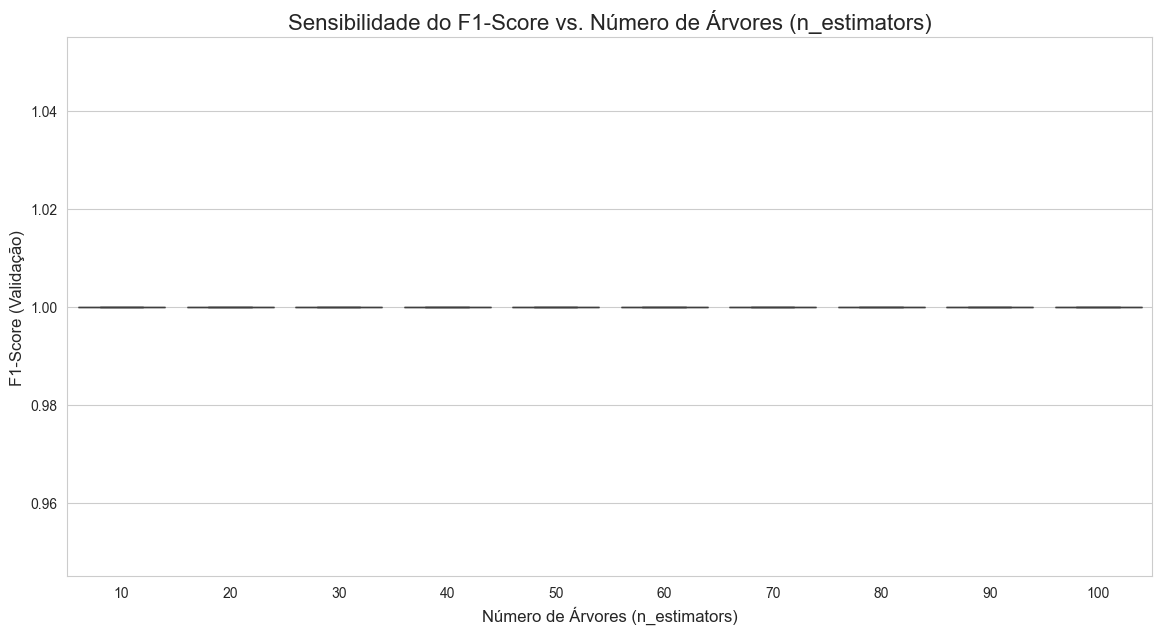

In [8]:
# Gráfico 1: Sensibilidade da Precisão (F1-Score)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='f1_score', data=results_df)
plt.title('Sensibilidade do F1-Score vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

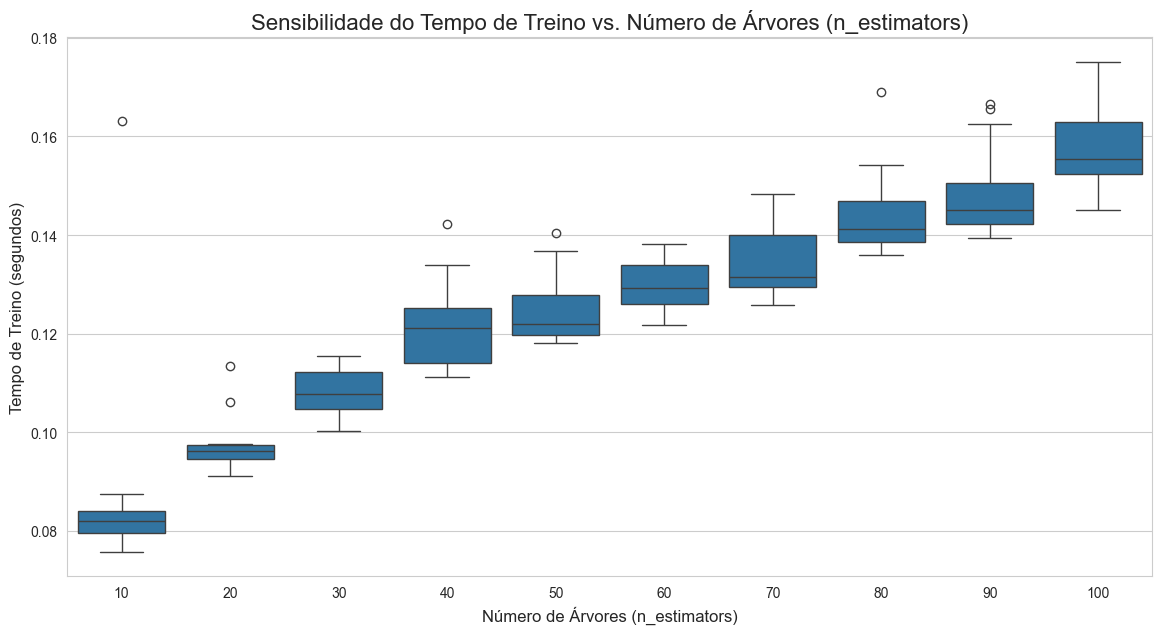

In [9]:
# Gráfico 2: Sensibilidade do Custo Computacional (Tempo de Treino)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='train_time', data=results_df)
plt.title('Sensibilidade do Tempo de Treino vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

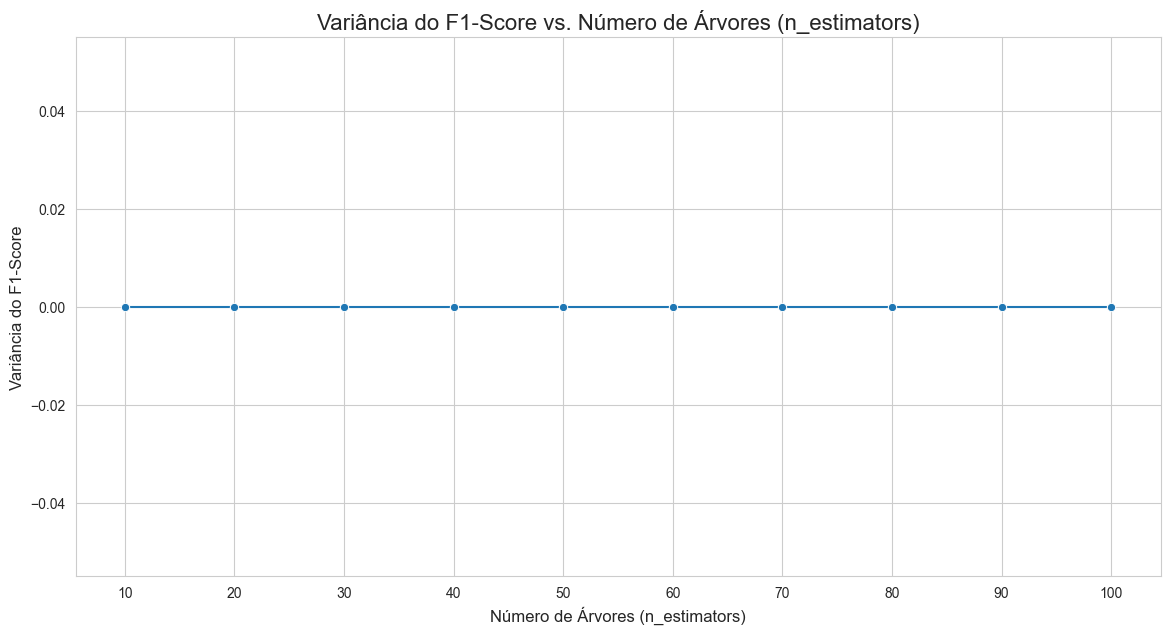

In [10]:
# Gráfico 3: Análise de Estabilidade (Variância)
variance_df = results_df.groupby('n_estimators')['f1_score'].var().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='n_estimators', y='f1_score', data=variance_df, marker='o')
plt.title('Variância do F1-Score vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Variância do F1-Score', fontsize=12)
plt.xticks(param_grid['n_estimators'])
plt.show()

--- Otimização do Limiar de Decisão (Validation Set) ---
ROC AUC no conjunto de validação: 1.0000
PR AUC (Precision-Recall) no conjunto de validação: 1.0000
Melhor Limiar encontrado: 0.9102
F1-Score correspondente no conjunto de validação: 1.0000


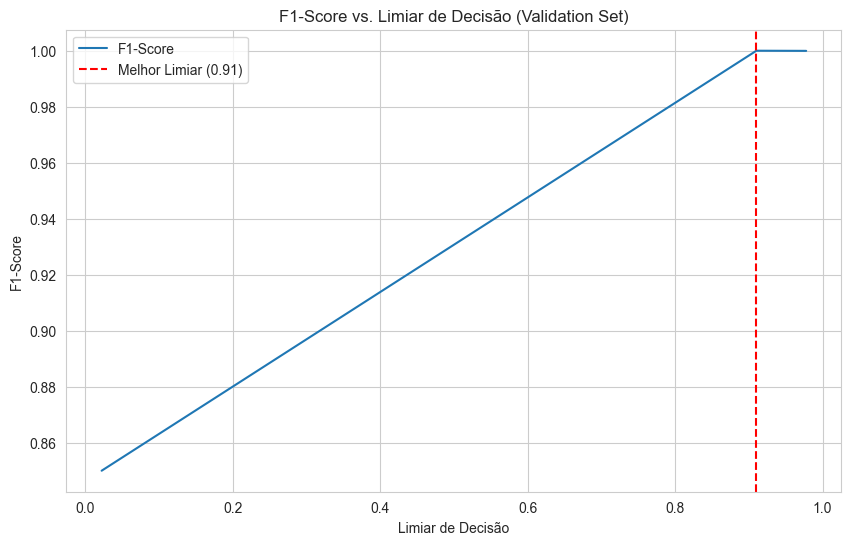

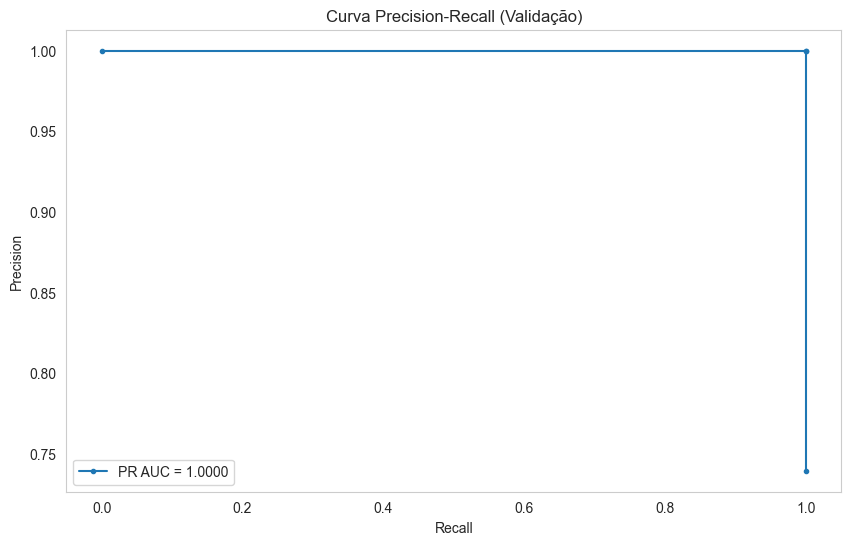

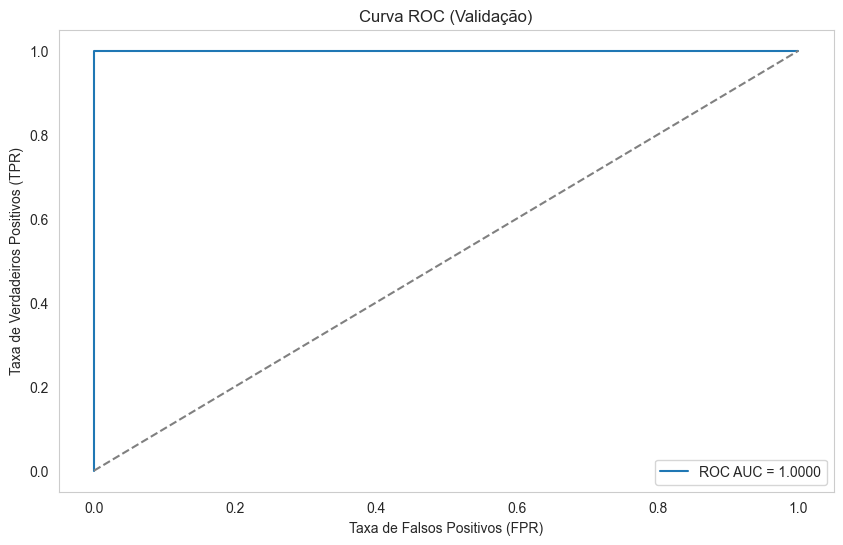

In [11]:
# Otimização do Limiar de Decisão

from sklearn.metrics import precision_recall_curve

print("--- Otimização do Limiar de Decisão (Validation Set) ---")

# Usar o melhor modelo já treinado durante o grid search
# (Aqui vamos re-treinar um modelo com os melhores hiperparâmetros para obter as probabilidades)
final_n_estimators = int(best_params['n_estimators'])
final_max_depth = best_params['max_depth']
if pd.isna(final_max_depth):
    final_max_depth = None
else:
    final_max_depth = int(final_max_depth)
best_params_dict = {
    'n_estimators': final_n_estimators,
    'max_depth': final_max_depth,
    'random_state': 42,
    'n_jobs': -1
}

model_for_tuning = XGBClassifier(**best_params_dict)
model_for_tuning.fit(X_train_resampled, y_train_resampled)

# Obter as probabilidades de previsão para a classe positiva (Anomalia) no conjunto de validação
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# Calcular precisão, recall e limiares
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)

# Calcular F1-score para cada limiar
# Adicionamos um epsilon para evitar divisão por zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Calcular ROC AUC (usando y_val e probabilidades)
roc_auc_val = roc_auc_score(y_val, y_probs_val)

# Calcular PR AUC (área sob a curva precisão-recall)
pr_auc_val = auc(recall, precision)

print(f"ROC AUC no conjunto de validação: {roc_auc_val:.4f}")
print(f"PR AUC (Precision-Recall) no conjunto de validação: {pr_auc_val:.4f}")

# Encontrar o melhor limiar que maximiza o F1-score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Melhor Limiar encontrado: {best_threshold:.4f}")
print(f"F1-Score correspondente no conjunto de validação: {best_f1:.4f}")

# Plotar a curva
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel("Limiar de Decisão")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Limiar de Decisão (Validation Set)")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

# Curva Precision-Recall
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc_val:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Validação)')
plt.legend()
plt.grid()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_probs_val)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_val:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC (Validação)') 
plt.legend()
plt.grid()
plt.show()

Formato do conjunto de treino final (X, y): (95029, 294), (95029,)
Distribuição final para treino com SMOTE: 1    70255
0    70255
Name: count, dtype: int64

Treinando o modelo final...
Treino concluído.

--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     24780
    Anomalia       0.56      1.00      0.72     31523

    accuracy                           0.56     56303
   macro avg       0.28      0.50      0.36     56303
weighted avg       0.31      0.56      0.40     56303


ROC AUC (Teste): 0.5000
PR AUC (Teste): 0.7799
--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

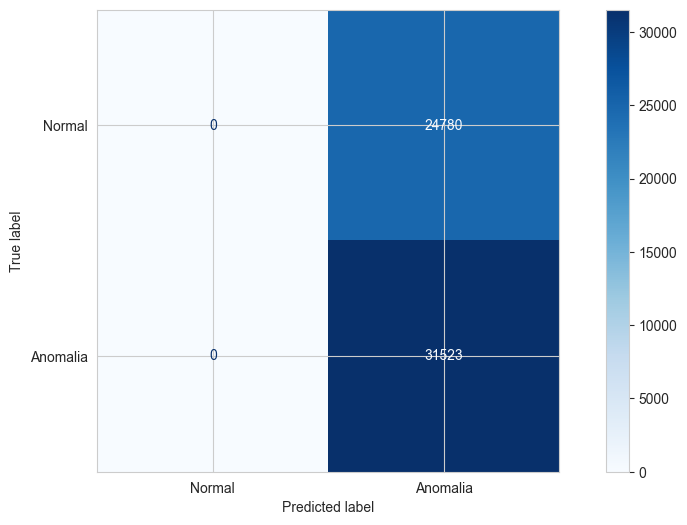

In [12]:
# Extrair os melhores parâmetros (convertendo None para o tipo correto se necessário)
final_n_estimators = int(best_params['n_estimators'])
final_max_depth = best_params['max_depth']
if pd.isna(final_max_depth):
    final_max_depth = None
else:
    final_max_depth = int(final_max_depth)


# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

# Aplicando o PCA para os dados de treino e validação
# --- # --- X_train_full_pca = pca.transform(X_train_full)
X_train_full_pca = X_train_full

print(f"Formato do conjunto de treino final (X, y): {X_train_full.shape}, {y_train_full.shape}")

smote_final = SMOTE(random_state=42)
X_train_full_resampled, y_train_full_resampled = smote_final.fit_resample(X_train_full_pca, y_train_full)
print("Distribuição final para treino com SMOTE:", pd.Series(y_train_full_resampled).value_counts())

# Instanciar o modelo final com os melhores hiperparâmetros
final_model = XGBClassifier(
    n_estimators=final_n_estimators,
    max_depth=final_max_depth,
    random_state=42,
    scale_pos_weight=2.83,
    n_jobs=-1
)


# Treinar o modelo final
print("\nTreinando o modelo final...")
final_model.fit(X_train_full_resampled, y_train_full_resampled)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test_pca)[:, 1]

# Aplicar o melhor limiar encontrado
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Métricas no conjunto de teste com limiar otimizado
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_pred_test_probs)
pr_auc_test = auc(recall_test, precision_test)

print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")
print(f"PR AUC (Teste): {pr_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()